In [1]:
# conda activate chronocell

import os
import sys
import time
import pickle
import pandas as pd

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint/code")

import Chronocell
from reconstruct_RNA_history import *

from threadpoolctl import threadpool_limits
threadpool_limits(10)

In [2]:
# Get traj object from running Chronocell
import pickle
with open("eLNPs_var>1.5_208_genes_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [3]:
Y = traj.X
Q = traj.Q[:, 0, :] 
tau = traj.tau # State transition times (global)
t = traj.t
theta = traj.theta
topo = traj.topo
state_grid = np.searchsorted(tau, t, side="left") - 1
state_grid[0] = 0 

# Do this below with subset of genes

# theta_ = theta.copy()
# a0 = theta_[:, 0] # Starting RNA abundance 
# a = theta_[:, 1:len(topo.flatten())] 
# beta = theta_[:, -2] # Splicing rate
# alpha = a * beta[:, None] # These values are divided by splicing rate; removing this factor now
# gamma = theta_[:, -1] # Degradation rate

## Subset to genes with protein measurements

In [4]:
genes = pd.read_csv("eLNPs_var>1.5_208_genes.csv")
shared_genes = pd.read_csv("RNA_vs_ADT_corr_meanExpr.csv")
gene_idx = genes['Gene_symbol'].isin(shared_genes['Gene']).tolist()

### What is the max # of counts for these genes?

In [5]:
shared_genes_mean_expr_U = Y[:, gene_idx, 0].max(axis=0)
shared_genes_mean_expr_S = Y[:, gene_idx, 1].max(axis=0)

In [6]:
np.sort(shared_genes_mean_expr_U)

array([  1.,   1.,   1.,   1.,   2.,   2.,   3.,   3.,   3.,   3.,   3.,
         3.,   3.,   4.,   4.,   4.,   4.,   5.,   6.,   6.,   6.,   6.,
         6.,   7.,   7.,   7.,   9.,  10.,  11.,  11.,  12.,  14.,  14.,
        16.,  16.,  16.,  19.,  19.,  22.,  22.,  24.,  25.,  27.,  27.,
        38.,  42.,  46.,  54.,  56.,  60., 115.])

In [7]:
np.sort(shared_genes_mean_expr_S)

array([  3.,   4.,   4.,   4.,   5.,   5.,   5.,   5.,   6.,   6.,   7.,
         7.,   7.,   7.,   7.,   8.,   8.,   8.,   8.,   8.,   8.,   9.,
        10.,  10.,  10.,  11.,  11.,  11.,  12.,  12.,  12.,  13.,  13.,
        14.,  16.,  16.,  16.,  18.,  20.,  21.,  25.,  27.,  27.,  28.,
        35.,  35.,  41.,  43.,  54.,  99., 105.])

In [8]:
Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [9]:
# Gene names

genes = pd.read_csv("eLNPs_var>1.5_208_genes.csv")
shared_genes = pd.read_csv("RNA_vs_ADT_corr_meanExpr.csv")
gene_idx = genes['Gene_symbol'].isin(shared_genes['Gene']).tolist()
gene_df = genes['Gene_symbol'][gene_idx]

In [19]:
gene_df

3         Cxcr4
9          Icos
12         Cd48
15        Sbno2
18        Cd24a
22         Cd63
25         Cd68
28         Ccr7
33       Havcr2
48         Ighm
62         Cd83
69       Lgals3
72         Il7r
76         Ly6a
82         Ly6e
88         Cd86
90        Cd200
93         Cd80
94         Btla
108       Cd274
109         Fas
115        Dpp4
124       Il2ra
126       Itga4
128       Procr
134       Cd1d1
137       Vcam1
148     Tnfrsf4
149    Tnfrsf18
150        Cd36
155       Sbno1
156        Flt3
157        Cd38
158         Kit
165         Cd9
167        Cd69
169       Klrk1
173        Cd8a
175     Clec12a
176      Clec9a
178        Pirb
180         Ilk
182       Il4ra
183       Itgal
184       Itgax
186        Bst2
190       Lamp1
194       Itgb1
200        Xcr1
202       Icam1
204        Jaml
Name: Gene_symbol, dtype: object

In [15]:
outdir = "data/RNA_history_per_gene"

## Reconstruct RNA

In [10]:
from threadpoolctl import threadpool_info
threadpool_info()

[{'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 10,
  'prefix': 'libopenblas',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libopenblasp-r0.3.29.so',
  'version': '0.3.29',
  'threading_layer': 'pthreads',
  'architecture': 'SkylakeX'},
 {'user_api': 'openmp',
  'internal_api': 'openmp',
  'num_threads': 10,
  'prefix': 'libgomp',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libgomp.so.1.0.0',
  'version': None}]

In [ ]:
sparse_cutoff = 50

In [ ]:
X_fwd_per_gene = []
states_per_gene = []
# X_bw_per_gene = []

n_genes = Y.shape[1]

for gene_idx in range(0, n_genes):
    # Set max # of RNAs based on observed values
    U_max, S_max = max_RNAs(Y, gene_idx)

    print("==================================")
    print(f"Starting gene {gene_idx + 1} out of {n_genes}")
    print("U_max, S_max:", U_max, S_max)
    
    gene_name = gene_df.iloc[gene_idx]
     
    states, index_for = enumerate_states(U_max, S_max)

    beta_j = beta[gene_idx]
    gamma_j = gamma[gene_idx] 
    alpha_j = alpha[gene_idx, :]
    Y_j = Y[:, gene_idx, :]

    # Make generator matrix (per transcription rate)
    A = []
    for i in range(0, alpha.shape[1]):
        rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
        if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
            A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
        else:
            A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
        A.append(A1)
    
    # Calculate forward probability distributions (needed for reverse generator)
    alpha0 = a0[gene_idx] * beta_j
    pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    start = time.perf_counter() 
    X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
    end = time.perf_counter()
    print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
    # Calculate backward probability distributions
    
    start = time.perf_counter()
    if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
        X_bw = backward_distribution_sparse_to_dense(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution_sparse_to_dense(): {end - start:.6f} seconds")
    else:
        X_bw = backward_distribution(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution(): {end - start:.6f} seconds")

    # Save highest probability state
    start = time.perf_counter()
    U_per_cell, S_per_cell = highest_prob_state_in_X_bw(X_bw, Q, states) 
    end = time.perf_counter()
    print(f"Elapsed time for highest_prob_state_in_X_bw(): {end - start:.6f} seconds")
         
    with open(f"{outdir}/eLNPs_var>1.5_208_genes_{gene_name}_U_RNA_history.pkl", "wb") as f:
        pickle.dump(U_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    with open(f"{outdir}/eLNPs_var>1.5_208_genes_{gene_name}_S_RNA_history.pkl", "wb") as f:
        pickle.dump(S_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    X_fwd_per_gene.append(X_fwd)
    states_per_gene.append(states)
    # X_bw_per_gene.append(X_bw)
    
    get_expm.cache_clear()
    get_A_rev.cache_clear()
    get_expm_rev.cache_clear()
    get_A_rev_sparse_to_dense.cache_clear()
    get_expm_rev_sparse_to_dense.cache_clear()

In [ ]:
# # import gzip

# with open("eLNPs_var>1.5_208_genes_X_fwd_per_gene.pkl", "wb") as f:
#     pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
# with open("eLNPs_var>1.5_208_genes_states_per_gene.pkl", "wb") as f:
#     pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
# # with open("eLNPs_var>1.5_208_genes_X_bw_per_gene.pkl.gz", "wb") as f:
# #     pickle.dump(X_bw_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

## Compare reconstructed vs. forward trajectories

In [30]:
with open("eLNPs_var>1.5_208_genes_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open("eLNPs_var>1.5_208_genes_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)

(array([  164,   458,   625, ..., 21311, 21314, 21315]),)

In [ ]:
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")
from protein_from_RNA import *

n = 1000
random_seed = 666

Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [ ]:
import glob
import matplotlib.pyplot as plt

In [108]:
gene_idx = 20

In [109]:
# Get forward states
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

In [110]:
# Load backward states
gene_str = gene_df.iloc[gene_idx]
pattern = os.path.join(outdir, f"*_{gene_str}_S*")
file = glob.glob(pattern)[0]

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

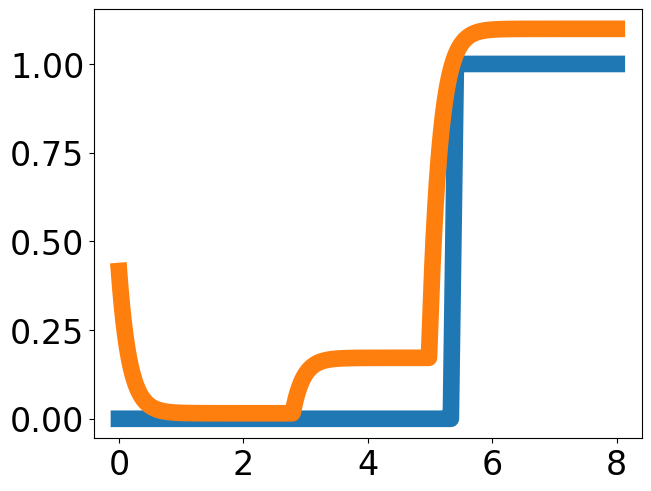

In [111]:
plt.plot(t, U_fwd)
plt.plot(true_t, Y[:, gene_idx, 0])

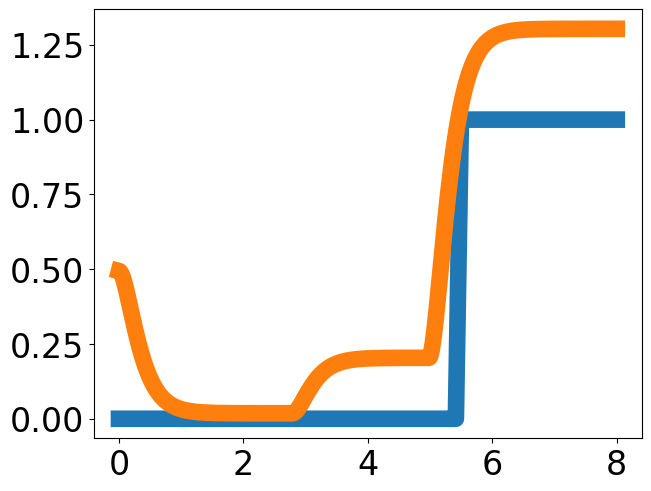

In [112]:
plt.plot(t, S_fwd)
plt.plot(true_t, Y[:, gene_idx, 1])

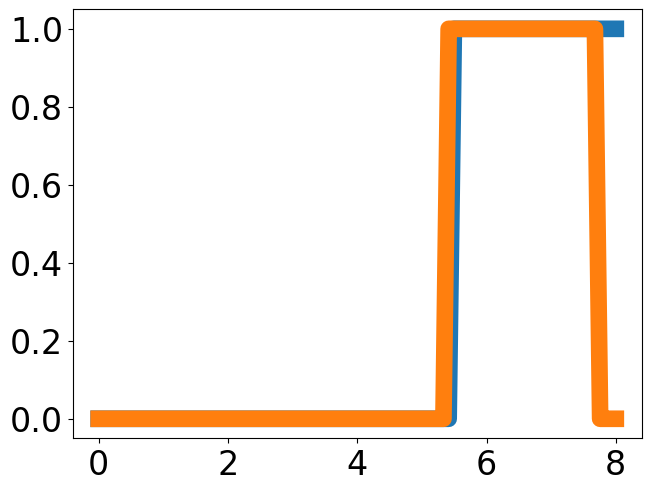

In [121]:
# Pick cell at the end of trajectory:

t_obs = np.argmax(Q, axis=1)
end_cells = np.where(t_obs == 99)[0]
X_bw_S_mean = X_bw_S[end_cells, :].mean(axis=1)

plt.plot(t, S_fwd)
plt.plot(t, X_bw_S[end_cells[19], :])

### Sparse implementation

In [ ]:
# X_bw_per_gene = []
# states_per_gene = []
    
# for gene_idx in range(0, Y.shape[1]):
#     print("Starting gene", gene_idx)

#     # Set max # of RNAs based on observed values for a given gene
#     U_max, S_max = max_RNAs(Y, gene_idx)
    
#     print("U_max, S_max:", U_max, S_max)

#     states, index_for = enumerate_states(U_max, S_max)
    
#     beta_j = beta[gene_idx]
#     gamma_j = gamma[gene_idx] 
#     alpha_j = alpha[gene_idx, :]
    
#     # Make generator matrix (per transcription rate)
#     A = []
#     for i in range(0, alpha.shape[1]):
#         rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
#         A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
#         A.append(A1)
    
#     # Calculate forward probability distribution (needed for reverse generator)
#     alpha0 = a0[gene_idx] * beta_j
#     pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    
#     start = time.perf_counter()
#     X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
#     end = time.perf_counter()
#     print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")

#     # Calculate backward probability distribution

#     start = time.perf_counter()
#     X_bw = backward_distribution_sparse_to_dense(Y[:, gene_idx, :], Q, states, index_for, t, tau, state_grid)
#     end = time.perf_counter()
#     print(f"Elapsed time for backward_distribution_sparse_to_dense(): {end - start:.6f} seconds") 
#     print("----------------")
    
#     X_bw_per_gene.append(X_bw)
#     states_per_gene.append(states)
    
#     get_A_rev_sparse.cache_clear()

In [ ]:
# Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta[0, :][None, :], n=20000, random_seed=666)